In [6]:
from pathlib import Path
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from flowing import flowtime_to_radius, radius_to_flowtime
from measurements import *

In [2]:
ns = 64
nt = 16

flowtimes = np.array([ 0.02572923590301565, 0.05303278154520656, 0.08103495224784385, 0.110208782326772, 0.141058391298962, 0.1736893835495303,
                       0.2086835114617738, 0.2454549361253429, 0.2838117228448263, 0.3249152519239425, 0.3705101434001126, 0.4179449298122797,
                       0.4696233239687699, 0.5279559816139976, 0.5890993819917063, 0.6570215111572449, 0.734680305158274, 0.8257738792221512,
                       0.9353328035912798, 1.06959076807306, 1.233820281085228, 1.435936459574629 ], dtype=float)#, 1.68034447439404, 1.972161672512587 ]

local_tol = 3.00e-04    # flowtimes based on this (not used here)
flow_type = 'zeuthen'   # just for information, prabably not needed

In [4]:
# load in correlation ensemble data
home_path = Path('/home/ln29bamu')
code_path = home_path / 'code' / 'milc_luis'

skip_configs = 50
all_corrs = np.load(code_path / 'zeugs' / 'outputs' / '16x64flows' / 'data0.npy')[skip_configs:]
print(all_corrs.shape, all_corrs.dtype)

# numbers of configs, flowtimes, time and spatial separations
n_cofigs, n_flows, n_tau, n_r = all_corrs.shape
print(f'\n{n_cofigs = }\n{n_flows  = }\n{n_tau    = }\n{n_r      = }')

# list of all spatial separations, list of multiplicities of each spatial separation
r_list  = np.array(radial_separations(ns), dtype=float)
dr_list = np.array(make_distance_corr_arrays(radial_multiplicities(ns), False), dtype=float)

# sample mean, sample std, std of sample mean
avg_corrs = all_corrs.mean(axis=0)              # sample mean
std_corrs = all_corrs.std(axis=0, ddof=1)       # sample standart deviation
sem_corrs = std_corrs / np.sqrt(n_cofigs)       # standart deviation of sample mean

(1005, 22, 9, 1914) float64

n_cofigs = 1005
n_flows  = 22
n_tau    = 9
n_r      = 1914


Correlation between $G_t(\tau, r)$ with different radial separations.
- Does not visibly depend on $\tau$ (should get slightly less correlated for larger $\tau$ I think)
- no correlation for $t=0$, correlation grows with growing flowtime $t$

(100, 100) float64


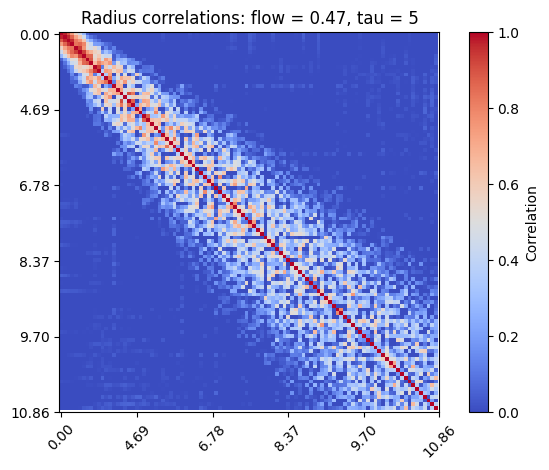

2.99e+08


In [8]:
iflow = 12
tau   = 5
r_cut = 100

covmat = np.cov(all_corrs[:, iflow, tau, :r_cut], rowvar=False)
cormat = np.corrcoef(all_corrs[:, iflow, tau, :r_cut], rowvar=False)
print(cormat.shape, cormat.dtype)


plt.imshow(cormat, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(label='Correlation')
plt.title(f"Radius correlations: flow = {flowtimes[iflow]:.2f}, tau = {tau}")

tick_step      = 20
tick_positions = np.arange(0, len(r_list[:r_cut])+1, tick_step)
tick_labels    = [f"{r_list[i]:.2f}" for i in tick_positions]

plt.xticks(tick_positions, tick_labels, rotation=45)
plt.yticks(tick_positions, tick_labels)

plt.tight_layout()
plt.show()


cond = np.linalg.cond(cormat)
print(f'{cond:.2e}')

(22, 22) float64


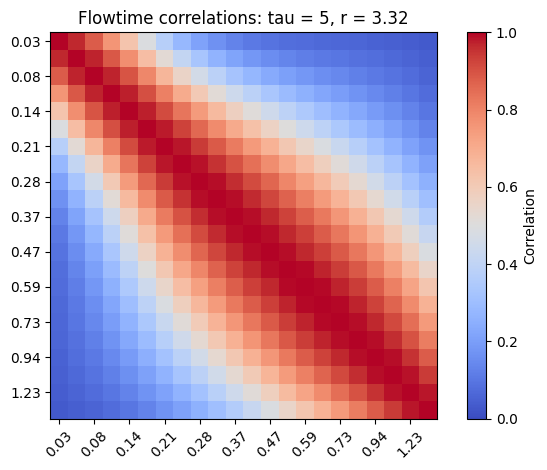

In [26]:
ir  = 10
tau = 5

cormat = np.corrcoef(all_corrs[:, :, tau, ir], rowvar=False)
print(cormat.shape, cormat.dtype)


plt.imshow(cormat, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(label='Correlation')
plt.title(f"Flowtime correlations: tau = {tau}, r = {r_list[ir]:.2f}")

tick_step      = 2
tick_positions = np.arange(0, len(flowtimes), tick_step)
tick_labels    = [f"{flowtimes[i]:.2f}" for i in tick_positions]

plt.xticks(tick_positions, tick_labels, rotation=45)
plt.yticks(tick_positions, tick_labels)

plt.tight_layout()
plt.show()